# TP 2 MathsInfo1 (Corrigé)

## Exercice 1 (erreur d'arrondi). 

On considère la suite $x_n$, $n\ge2$ définie par 

$\quad x_2 = 2$

$\quad x_{n+1} = 2^{n-\frac{1}{2}}\sqrt{1-\sqrt{1-4^{1-n}x_n}},\quad n=2,3,\dots$

Cette suite converge vers $\pi$. 

1) Ecrire un programme pour évaluer les 30 premiers termes de cette suite. On gardera les termes dans un tableau. 

2) Représenter graphiquement $x_n$ en fonction de $n$. 

3) Calculer ensuite l'erreur relative

$\quad e_n = \frac{|x_n-\pi|}{|\pi|}$

Représenter graphiquement $e_n$ en fonction de $n$

4) Représenter graphiquement le logarithme de $e_n$ en fonction de $n$ 


[2.         2.82842712 3.06146746 3.12144515 3.13654849 3.14033116
 3.14127725 3.1415138  3.14157294 3.14158773 3.14159142 3.14159235
 3.14159258 3.14159263 3.14159265 3.14159268 3.14159276 3.14159291
 3.14159413 3.14159655 3.14159655 3.14167427 3.14182968 3.14245127
 3.14245127 3.16227766 3.16227766 3.46410162 4.         8.        ]
[3.63380228e-01 9.96836838e-02 2.55046416e-02 6.41314886e-03
 1.60560696e-03 4.01546850e-04 1.00395784e-04 2.50995130e-05
 6.27491342e-06 1.56872974e-06 3.92184886e-07 9.80326701e-08
 2.45241178e-08 6.40647807e-09 3.87636675e-10 9.44645619e-09
 3.36033084e-08 8.19170109e-08 4.68426547e-07 1.24144517e-06
 1.24144517e-06 2.59777256e-05 7.54484510e-05 2.73306886e-04
 2.73306886e-04 6.58424209e-03 6.58424209e-03 1.02657791e-01
 2.73239545e-01 1.54647909e+00]


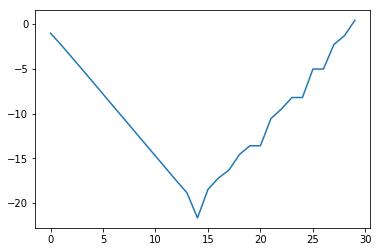

In [2]:
import numpy as np
import matplotlib.pyplot as plt
pi = np.pi
N = 30
xn = np.zeros(N)  # tableau avec N zeros
xn[0]=2.0         # point initial 
for k in range(N-1): # 0 <= k <= N-2
    n=k+2         # 2 <= n <= N, pour évaluer la formule
    xn[k+1] = (2**(n-1/2))*np.sqrt(1-np.sqrt(1-(xn[k]**2)*(4**(1-n))))

print(xn)
#plt.plot(xn)
en = abs(xn - pi)/pi  # calcul de l'erreur relative
print(en)
plt.plot(np.log(en))  # graphique du log de l'erreur

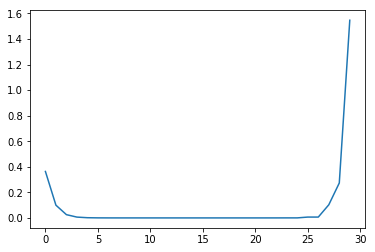

In [4]:
plt.plot(en)
# dans les premiers itérations l'erreur décroit comme C^k (avec C < 1) (c'est la droite décroissante dans le graphique de log(en) ci-dessus)
# puis à cause des erreurs d'arrondi l'erreur explose...

## Exercice 2 (Ordre d'une approximation). 

On considère la formule de Taylor-Lagrange appliquée à la fonction exponentielle $x\mapsto e^x$ au voisinage de $0$ : 

$\quad e^x = \displaystyle\sum_{k=0}^{n}\frac{1}{k!}x^k  + e^{\xi}\frac{x^{n+1}}{(n+1)!}$,

où $\xi$ est entre $0$ et $x$. Une approximation de $e^x$ est donc $P_n(x)=\displaystyle\sum_{k=0}^{n}\frac{1}{k!}x^k$.

Comme la fonction exponentielle est croissante alors, si $x>0$, l'erreur de l'approximation sera telle que  

$$ e_T = |e^x - P_n(x)| = |e^{\xi}\frac{x^{n+1}}{(n+1)!}| \leq e^{x}\frac{x^{n+1}}{(n+1)!} $$

L'objectif de l'exercice est étudier le comportement de l'approximation $P_n$ et de l'erreur $e_T$ pour différents valeurs de $x$ et de $n$ 

Pour cela, programmer l'algorithme suivante : 

1) Soient $n$ le degré du polynôme de Taylor et x le point d'abscisse. 

2) Soient les variables S (pour garder les valeurs de la somme), fk (pour garder 1/k!) et xk (pour garder x^k)

3) Initialisiation S = 1, f=1, xk = 1

4) pour k entre 1 et n faire
   
      fk = fk*(1/k)
   
      xk = xk*x
   
      S = S + f*xk

fin

5) retourner S

On pourra programmer une fonction  (def taylorexp(x,n): ... return Pn) avec l'algorithme ci-dessus


In [6]:
import numpy as np
def taylorexp(x,n):
    S = 1. #initialisation
    fk = 1.
    xk = 1.
    for k in range(1,n+1):   # 1 <= k < n+1
        fk=fk/k
        xk = xk*x
        S = S + fk*xk  
    return S

x=0.1
n=10
print(taylorexp(x,2), np.exp(x)) # affichage du dev avec n=2 au point x=0.1 et de la valeur exacte

1.105 1.1051709180756477


a) Calculer, avec la fonction précédente, les valeurs approchées de $e^x$ pour $x=0,2$ et $n=1,2,\dots 5$. Calculer l'erreur $e_T$ ainsi que la borne de l'erreur $\displaystyle e^{x}\frac{x^{n+1}}{(n+1)!}$ et comparer.

Pour la valeur exacte de $e^x$, on pourra utiliser la fonction math.exp() (ou numpy.exp()). Pour calculer $n!$ on pourra utiliser math.factorial().

In [14]:
import math as m
x=0.2
N=np.linspace(1,5,5)
print(N)
for n in range(5): #on fait varier n entre 0 et 4
    Pn = taylorexp(x,n+1)    # on calcule le dev à l'ordre n+1
    eT = abs(Pn - np.exp(x)) # on calcule l'erreur 
    Be = (np.e**x)*(x**(n+2))/m.factorial(n+2) # on calcule la borne de l'erreur
    print(Pn,eT,np.e**x, Be)  #on affiche les résultats 
# fin boucle

[1. 2. 3. 4. 5.]
1.2 0.0214027581601699 1.2214027581601699 0.024428055163203403
1.22 0.0014027581601698813 1.2214027581601699 0.0016285370108802268
1.2213333333333334 6.942482683647277e-05 1.2214027581601699 8.142685054401135e-05
1.2214 2.7581601698134506e-06 1.2214027581601699 3.2570740217604537e-06
1.2214026666666666 9.149350321813188e-08 1.2214027581601699 1.085691340586818e-07


[1. 2. 3. 4. 5.]
[0.0214027581601699, 0.0014027581601698813, 6.942482683647277e-05, 2.7581601698134506e-06, 9.149350321813188e-08]
[0.024428055163203403, 0.0016285370108802268, 8.142685054401135e-05, 3.2570740217604537e-06, 1.085691340586818e-07]


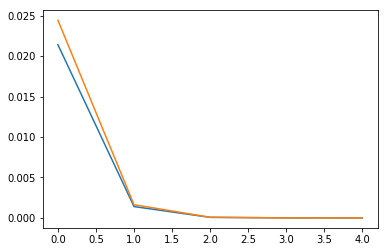

In [18]:
# deuxième version avec graphiques et listes
import numpy as np 
x=0.2
N=np.linspace(1,5,5)
print(N)
Pn=[]    # on crée des listes vides
eT=[]
Be=[]
for n in range(5): #on fait varier n entre 0 et 4
    p = taylorexp(x,n+1)  # on calcule le dev à l'ordre n+1
    Pn.append(p)          # on la rajoutte à la liste 
    eT.append(abs(p - np.exp(x))) # on calcule l'erreur 
    Be.append((np.e**x)*(x**(n+2))/m.factorial(n+2)) # on calcule la borne de l'erreur
#    print(Pn,eT,np.e**x, Be)  #on affiche les résultats 
# fin boucle
print(eT)
print(Be)
plt.plot(eT)
plt.plot(Be)
# et on vérifie que l'erreur absolue et plus petite que la borne calculée. 

## Définition : 
Une fonction $x\mapsto f(x)$ est en grand ordre de $x^n$ au voisinage de $0$, s'il exite $C>0$ tel que 

$$ \frac{|f(x)|}{|x^n| } \le C  $$

On note $f(x) = {\cal O}(x^n)$.

On peut voir que si $x\in ]-a,a[$, alors le terme d'erreur de la formule de Taylor-Lagrange est en grand ordre de $x^{n+1}$ (avec la constante $C = e^a/(n+1)!$). 

Dans la suite de l'exercice on va vérifier numériquement cette propriété. 

b) On considère $n=5$ fixe. Calculer $e_T$ pour $x\in\{0,0625,\, 0,125,\, 0,25,\, 0,5,\,1,0\}$. 
Représenter graphiquement $e_T$ en fonction de $x$, puis $\log(e_T)$ en fonction de $\log(x)$. 

Remarque : Noter que si $e(x) = Cx^n$, $x>0$, alors $log(e(x)) = n\log(x) + \log(C)$. 

[8.35289615e-11 5.39430034e-09 3.51583574e-07 2.33540335e-05
 1.61516179e-03]


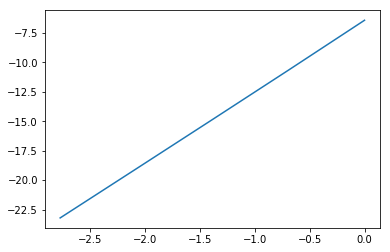

In [20]:
import matplotlib.pyplot as plt #...
x=np.array([1/16, 1/8, 1/4, 1/2, 1]) # on crée un array (numpy) avec les valeurs de x 
et = abs(taylorexp(x,5)-np.e**x)     # on peut appliquer la fonction taylorexp a l'array x, le résultat est un array
print(et)
#plt.plot(x,et)

plt.plot(np.log(x),np.log(et))  # graphique de log(et) en ordonnée et log(x) en abscisse 
#plt.plot(x,et)
# on obtient une droite croissante car d'après l'analyse e(x) = Cx^n 

c) Calculer $n_i = \log(e_i/e_{i-1})/log(x_i/x_{i-1})$, $i=1,\dots,5$.  Expliquer les résultats.

Remarque : Noter que $ \log(e_i/e_{i-1})/log(x_i/x_{i-1}) = \displaystyle\frac{ \log(e_i)-\log(e_{i-1})}{\log(x_i)-\log(x_{i-1})}$. 

In [21]:
ni=np.log(et[1:5]/et[0:4])/np.log(x[1:5]/x[0:4])
print(ni)
# on observe que les quotients tendent vers 6. D'après la remarque chaque quotient corréspond à un taux 
#d'accroissement, donc si  on fait tendre x_i à 0 à la limite on devrait trouver la dérive de log(e(x)), i.e.
# n= 6 (la pente de la droite).

[6.01301554 6.02628801 6.05366026 6.11186314]


d) On fixe $x=20$. Calculer $P_n(x,0)$ et $P_n(-x,0)$ pour   $n\in\{10,20,30,50,60, 70, 80\}$. Calculer $P_n(x)$ l'erreur 

$$ e_T(n) = |P_n(x) - e^x| $$

Comment pourrait-on expliquer les resultats observés ? 

In [66]:
# on fait les calculs avec x=-20 
x=-20
N = np.linspace(10,80,8,dtype=int) # tableau avec 8 points équidistants entre 10 et 80
print(N)
Pn = np.zeros(8)
eT = np.zeros(8)
for i in range(8):
    Pn[i] = taylorexp(x,N[i])
    eT[i] = abs(Pn[i]-np.e**(x))
print(Pn)
print(np.e**x)
print(eT)
# on observe que la valeur du polynôme et l'erreur avec les premiers valeurs de N sont très grands  
# (l'approximation est valable dans un voisinage de 0) mais avec les derniers valeurs l'erreur est de 
# l'ordre de 10^-9.
# Mais, si on regarde les valeurs du polynôme pour N=70 et N=80, on voit des valeurs négatives. 
# Or la fonction exponentielle est toujours positive

[10 20 30 40 50 60 70 80]
[ 1.85962368e+06  2.12772103e+07  1.59969410e+06  4.44203436e+03
  1.04691696e+00  3.43078812e-05 -7.16891640e-09 -7.38604961e-09]
2.06115362243856e-09
[1.85962368e+06 2.12772103e+07 1.59969410e+06 4.44203436e+03
 1.04691696e+00 3.43058200e-05 9.23007003e-09 9.44720323e-09]


e) Refaire d) avec $x=-20$. Est-ce que pour l'approximation de $e^{-20}$ est correcte pour les valeurs de $n$ grand ?



In [ ]:
# déjà fait ci-dessus


## Exercice 3. 

Dans l'exercice précédent, on a vu que le polynôme de Taylor est une bonne approximation de $e^x$ quand $x$ est petit. On a vu aussi que pour  $x$ loin de $0$ il serait nécessaire d'utiliser un polynôme de degré élevé pour avoir une approximation raisonable (mais dans certains cas, par exemple avec $x=-20$, incorrecte). 

Une manière d'éviter ce problème est la suivante : Soit $x\in\mathbb{R}$. Alors, il existe $M\in \mathbb{Z}$ et $s\in]-\ln{2}/2, \ln{2}/2[$ tels que

$$ x= M\ln(2) + s $$

Pour trouver $M$ et $N$ on considère deux cas : 

Cas $x>0$.  On considère la partie entière $N$ et la partie fractionnaire $f\in[0,1[$ de la division de $x$ par $\ln(2)$ : 

$$ x = N\ln(2) + f\ln(2) $$ 

(Noter que $f = r/\ln(2)$ où $r$ est le reste de la division de $x$ par $\ln(2)$ : $x = N\ln(2) + r$). 

Si $f\in[0,1/2]$ alors $M = N$ et $s = f\ln(2)$. Si $f\in]1/2,1[$ alors $M = N+1$ et $s = (f-1)\ln(2)$ (comme $f\in]1/2,1[$ alors $s\in]-ln(2)/2,0[$). 

Cas $x<0$. On calcule la décomposition de $|x|$, puis on multiplie les valeurs trouvées par $-1$. 

En utilisant la décomposition de $x$ on a alors 

$$ e^x = e^{M\ln(2) + s} = 2^{M}e^{s} $$

Donc, pour calculer une approximation de $e^x$ on a besoin de calculer une puissance (entière) de $2$ et une approximation de l'exponentielle dans l'intervalle $]-\ln{2}/2, \ln{2}/2[ \approx]-0,346573590, 0,346573590[ $. 

a) Ecrire une fonction qui calcule, pour un $x$ donné,  $M$ et $s$. 


In [23]:
def decompx(x):
    N=m.floor(abs(x)/m.log(2))
#    print(N)
    r = abs(x)/m.log(2) - N
# print(r)
    if r <= 0.5: 
        NN = N
        rr = r*m.log(2)
    else: 
        NN = N+1
        rr = (r-1)*m.log(2)
    if x<0:
        NN = -1*NN
        rr = -1*rr
    return(NN,rr)
# fin fonction

b) Calculer la décomposition de $x=20$ (on doit obtenir $M = 29$ et $s=  -0.10126823623841302$).

In [25]:
M=decompx(20)
print(M)
print(29*m.log(2) + -0.1012682362384147)



(29, -0.10126823623841302)
20.0


c) Ecrire une fonction qui calcule une approximation de $e^x$ en utilisant la décomposition de $x$ précédente et 
le polynôme de Taylor d'ordre $4$. Comparer avec la valeur obtenue en évaluant directement le polynôme en $x=-20$ et avec la valeur exacte obtenue avec m.exp().

In [112]:
def approxexp(x):
    D=decompx(x)
    M=D[0]
    s=D[1]
    v = (2**M)*taylorexp(s,4)
    return v

print(approxexp(-20))
print(m.exp(-20))
print(taylorexp(-20,6))

2.061153622397673e-09
2.061153622438558e-09
67736.55555555556
